In [1]:
import os
import json
import re
import numpy as np
from collections import defaultdict

BASE = "/kaggle/input/datasets/mnhlfuch/vqa-v2/VQA v2/VQA v2"
OUT_DIR = "/kaggle/working/preprocessed"

os.makedirs(OUT_DIR + "/Questions", exist_ok=True)
os.makedirs(OUT_DIR + "/Annotations", exist_ok=True)

# TOP_K = 1000

In [2]:
TRAIN_Q = BASE + "/Questions/v2_OpenEnded_mscoco_train2014_questions.json"
VAL_Q   = BASE + "/Questions/v2_OpenEnded_mscoco_val2014_questions.json"
TEST_Q  = BASE + "/Questions/v2_OpenEnded_mscoco_test2015_questions.json"

TRAIN_A = BASE + "/Annotations/v2_mscoco_train2014_annotations.json"
VAL_A   = BASE + "/Annotations/v2_mscoco_val2014_annotations.json"

Cleaning

In [3]:
regex = re.compile(r'[^\w\s]')

def clean_question(q):
    q = q.lower()
    q = regex.sub(' ', q)
    return q.strip()

def clean_answer(ans):
    ans = ans.lower()
    ans = regex.sub('', ans)
    return ans.strip()

## Question Vocab

In [4]:
import json

with open(TRAIN_Q, 'r') as f:
    data = json.load(f)

print(len(data['questions']))

print(data['questions'][0])

443757
{'image_id': 458752, 'question': 'What is this photo taken looking through?', 'question_id': 458752000}


In [5]:
import json

with open(VAL_Q, 'r') as f:
    data = json.load(f)

print(len(data['questions']))

print(data['questions'][0])

214354
{'image_id': 262148, 'question': 'Where is he looking?', 'question_id': 262148000}


In [6]:
def make_q_vocab():
    print("Building Question Vocabulary...")

    word_count = defaultdict(int)

    for path in [TRAIN_Q, VAL_Q]:
        with open(path, 'r') as f:
            data = json.load(f)

        for entry in data['questions']:
            question = clean_question(entry['question'])
            words = question.split()

            for word in words:
                word_count[word] += 1

    save_path = OUT_DIR + "/Questions/question_vocab.txt"

    with open(save_path, 'w') as f:
        for word, count in word_count.items():
            f.write(f"{word} {count}\n")

    print("Saved at:", save_path)
    return word_count

q_vocab = make_q_vocab()

Building Question Vocabulary...
Saved at: /kaggle/working/preprocessed/Questions/question_vocab.txt


### Answer Count

In [7]:
def make_answer_count():
    print("Building Answer Count...")

    answer_count = defaultdict(int)

    for path in [TRAIN_A, VAL_A]:
        with open(path, 'r') as f:
            data = json.load(f)

        for entry in data['annotations']:
            ans = clean_answer(entry['multiple_choice_answer'])
            answer_count[ans] += 1

    print("Total unique answers:", len(answer_count))
    return answer_count

answer_count = make_answer_count()

Building Answer Count...
Total unique answers: 28788


### Finding optimal value of TOP_K

In [8]:
def analyze_top_k(answer_count):
    print("\nAnalyzing Top-K coverage...")

    sorted_answers = sorted(answer_count.items(), key=lambda x: x[1], reverse=True)

    all_answers = []

    for path in [TRAIN_A, VAL_A]:
        with open(path, 'r') as f:
            data = json.load(f)

        for entry in data['annotations']:
            ans = clean_answer(entry['multiple_choice_answer'])
            all_answers.append(ans)

    total = len(all_answers)

    k_values = [500, 1000, 2000, 3000, 5000, 10000]

    for k in k_values:
        top_k = set([ans for ans, _ in sorted_answers[:k]])
        covered = sum(1 for ans in all_answers if ans in top_k)

        print(f"K={k:5d} → {covered/total*100:.2f}% coverage")

    return sorted_answers

sorted_answers = analyze_top_k(answer_count)


Analyzing Top-K coverage...
K=  500 → 82.80% coverage
K= 1000 → 87.40% coverage
K= 2000 → 91.18% coverage
K= 3000 → 93.03% coverage
K= 5000 → 94.95% coverage
K=10000 → 96.97% coverage


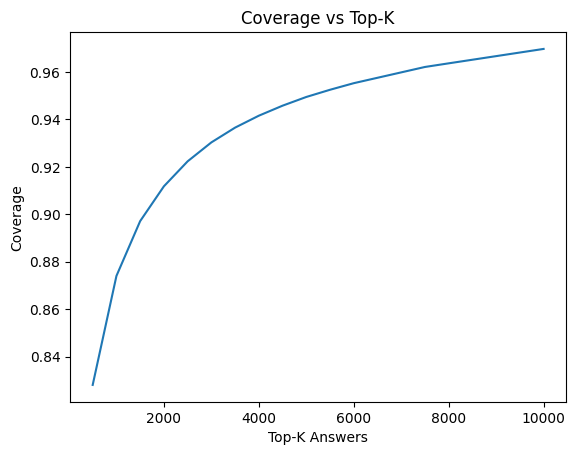

In [16]:
import matplotlib.pyplot as plt

ks = []
covs = []

all_answers = []

for path in [TRAIN_A, VAL_A]:
    with open(path, 'r') as f:
        data = json.load(f)

    for entry in data['annotations']:
        ans = clean_answer(entry['multiple_choice_answer'])
        all_answers.append(ans)

total = len(all_answers)

for k in range(500, 10001, 500):
    top_k = set([ans for ans, _ in sorted_answers[:k]])
    covered = sum(1 for ans in all_answers if ans in top_k)
    
    ks.append(k)
    covs.append(covered/total)

plt.plot(ks, covs)
plt.xlabel("Top-K Answers")
plt.ylabel("Coverage")
plt.title("Coverage vs Top-K")
plt.show()

In [17]:
TOP_K = 3000

## Answer Vocab

In [18]:
import json

with open(TRAIN_A, 'r') as f:
    data = json.load(f)

print(len(data['annotations']))

print(data['annotations'][0])

443757
{'question_type': 'what is this', 'multiple_choice_answer': 'net', 'answers': [{'answer': 'net', 'answer_confidence': 'maybe', 'answer_id': 1}, {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 2}, {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 3}, {'answer': 'netting', 'answer_confidence': 'yes', 'answer_id': 4}, {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 5}, {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 6}, {'answer': 'mesh', 'answer_confidence': 'maybe', 'answer_id': 7}, {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 8}, {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 9}, {'answer': 'net', 'answer_confidence': 'yes', 'answer_id': 10}], 'image_id': 458752, 'answer_type': 'other', 'question_id': 458752000}


In [19]:
def make_answer_vocab(sorted_answers, TOP_K):
    print("Building Answer Vocabulary...")

    answer_vocab = sorted_answers[:TOP_K]

    save_path = OUT_DIR + "/Annotations/answer_vocab.txt"

    with open(save_path, 'w') as f:
        for ans, count in answer_vocab:
            f.write(f"{ans} {count}\n")

    print("Saved at:", save_path)

make_answer_vocab(sorted_answers, TOP_K)

Building Answer Vocabulary...
Saved at: /kaggle/working/preprocessed/Annotations/answer_vocab.txt


## Preprocessing

### Load Top Answers

In [20]:
def load_top_answers():
    path = OUT_DIR + "/Annotations/answer_vocab.txt"
    top_answers = []

    with open(path, 'r') as f:
        for line in f:
            ans, _ = line.rsplit(" ", 1)
            top_answers.append(ans)

    return top_answers

### Match Top Answer

In [21]:
def match_top_ans(ans, top_answers):
    if ans not in top_answers:
        match_top_ans.unk += 1
        return "<unk>"
    return ans

match_top_ans.unk = 0
#unk is like a global variable for the function match_top_ans

### Preprocessing function

In [22]:
def preprocessing(question_path, annotation_path=None):

    print("Processing:", question_path)

    with open(question_path, 'r') as f:
        q_data = json.load(f)

    questions = q_data['questions']

    annotations = {}
    if annotation_path:
        with open(annotation_path, 'r') as f:
            a_data = json.load(f)

        annotations = {a['question_id']: a for a in a_data['annotations']}

    top_answers = load_top_answers()

    processed = []

    for q in questions:
        qid = q['question_id']
        image_id = q['image_id']
        question = q['question']

        if annotation_path:
            ans = clean_answer(annotations[qid]['multiple_choice_answer']).lower()
            ans = match_top_ans(ans, top_answers)
        else:
            ans = None

        processed.append({
            "question": question,
            "image_id": image_id,
            "answer": ans
        })

    return processed

In [23]:
train_data = preprocessing(TRAIN_Q, TRAIN_A)
val_data   = preprocessing(VAL_Q, VAL_A)
test_data  = preprocessing(TEST_Q, None)

Processing: /kaggle/input/datasets/mnhlfuch/vqa-v2/VQA v2/VQA v2/Questions/v2_OpenEnded_mscoco_train2014_questions.json
Processing: /kaggle/input/datasets/mnhlfuch/vqa-v2/VQA v2/VQA v2/Questions/v2_OpenEnded_mscoco_val2014_questions.json
Processing: /kaggle/input/datasets/mnhlfuch/vqa-v2/VQA v2/VQA v2/Questions/v2_OpenEnded_mscoco_test2015_questions.json


In [24]:
np.save(OUT_DIR + "/train.npy", np.array(train_data, dtype=object))
np.save(OUT_DIR + "/val.npy", np.array(val_data, dtype=object))
np.save(OUT_DIR + "/test.npy", np.array(test_data, dtype=object))

print("Saved all splits!")
print("Unknown answers:", match_top_ans.unk)

Saved all splits!
Unknown answers: 45872


### Total Questions = 6,58,111 (both training and validation)
### Unknown answers = 45872 
### Unknown answers ratio = 45872 / 6,58,111 ≈ 6.97%